<a href="https://colab.research.google.com/github/HeshanNavindu-7/oilspill-reseach/blob/main/optimized_edge_unet_oil_spill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm

dataset_path = '/content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset'
project_path = '/content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation'

SPILL_IDS = {2, 3, 5}   # emulsion, oil, sheen

IMG_SIZE = 224
BATCH_SIZE = 8
INITIAL_LR = 1e-4
FINE_TUNE_LR = 1e-5
EPOCHS_STAGE_1 = 20
EPOCHS_STAGE_2 = 10
AUTOTUNE = tf.data.AUTOTUNE

print("dataset_path:", dataset_path)
print("project_path:", project_path)

Mounted at /content/drive
dataset_path: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Lados Dataset
project_path: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation


Step 2 — Create folders

In [3]:
os.makedirs(project_path, exist_ok=True)

for folder in ['processed', 'models', 'plots', 'predictions', 'tflite']:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(project_path, 'processed', split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(project_path, 'processed', split, 'masks'), exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


Step 3 — Convert original masks into binary spill masks

In [4]:
def convert_split_to_binary(split_name):
    src_path = os.path.join(dataset_path, split_name)
    dst_img_path = os.path.join(project_path, 'processed', split_name, 'images')
    dst_mask_path = os.path.join(project_path, 'processed', split_name, 'masks')

    files = sorted(os.listdir(src_path))
    image_files = [
        f for f in files
        if f.lower().endswith(('.jpg', '.jpeg', '.png')) and '_mask' not in f.lower()
    ]

    total_images = 0
    total_masks = 0

    for img_file in tqdm(image_files, desc=f"Processing {split_name}"):
        base = os.path.splitext(img_file)[0]
        mask_file = base + "_mask.png"

        img_src = os.path.join(src_path, img_file)
        mask_src = os.path.join(src_path, mask_file)

        if not os.path.exists(mask_src):
            continue

        img = cv2.imread(img_src)
        mask = cv2.imread(mask_src, cv2.IMREAD_UNCHANGED)

        if img is None or mask is None:
            continue

        binary_mask = np.isin(mask, list(SPILL_IDS)).astype(np.uint8)

        cv2.imwrite(os.path.join(dst_img_path, img_file), img)
        cv2.imwrite(os.path.join(dst_mask_path, base + ".png"), binary_mask * 255)

        total_images += 1
        total_masks += 1

    print(f"{split_name}: saved {total_images} images and {total_masks} masks")

for split in ['train', 'valid', 'test']:
    convert_split_to_binary(split)

Processing train: 100%|██████████| 2370/2370 [04:46<00:00,  8.28it/s]


train: saved 2370 images and 2370 masks


Processing valid: 100%|██████████| 675/675 [01:07<00:00, 10.07it/s]


valid: saved 675 images and 675 masks


Processing test: 100%|██████████| 343/343 [00:35<00:00,  9.58it/s]

test: saved 343 images and 343 masks


Step 4 — Collect image and mask paths

In [5]:
def get_image_mask_paths(split_name):
    img_dir = os.path.join(project_path, 'processed', split_name, 'images')
    mask_dir = os.path.join(project_path, 'processed', split_name, 'masks')

    image_files = sorted(os.listdir(img_dir))
    mask_files = sorted(os.listdir(mask_dir))

    image_paths = [os.path.join(img_dir, f) for f in image_files]
    mask_paths = [os.path.join(mask_dir, f) for f in mask_files]

    return image_paths, mask_paths

train_image_paths, train_mask_paths = get_image_mask_paths('train')
valid_image_paths, valid_mask_paths = get_image_mask_paths('valid')
test_image_paths, test_mask_paths = get_image_mask_paths('test')

print("Train:", len(train_image_paths), len(train_mask_paths))
print("Valid:", len(valid_image_paths), len(valid_mask_paths))
print("Test :", len(test_image_paths), len(test_mask_paths))

Train: 2370 2370
Valid: 675 675
Test : 343 343


Step 5 — Build the tf.data pipeline

In [6]:
def read_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image

def read_mask(path):
    mask = tf.io.read_file(path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method='nearest')
    mask = tf.cast(mask > 127, tf.float32)
    return mask

def augment_pair(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    return image, mask

def load_pair(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)
    return image, mask

def make_dataset(image_paths, mask_paths, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    ds = ds.map(load_pair, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(min(len(image_paths), 512), reshuffle_each_iteration=True)
        ds = ds.map(augment_pair, num_parallel_calls=AUTOTUNE)

    ds = ds.cache()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_image_paths, train_mask_paths, training=True)
valid_ds = make_dataset(valid_image_paths, valid_mask_paths, training=False)
test_ds  = make_dataset(test_image_paths, test_mask_paths, training=False)

print("Datasets created.")

Datasets created.


Step 6 — Check one batch

Image batch shape: (8, 224, 224, 3)
Mask batch shape : (8, 224, 224, 1)


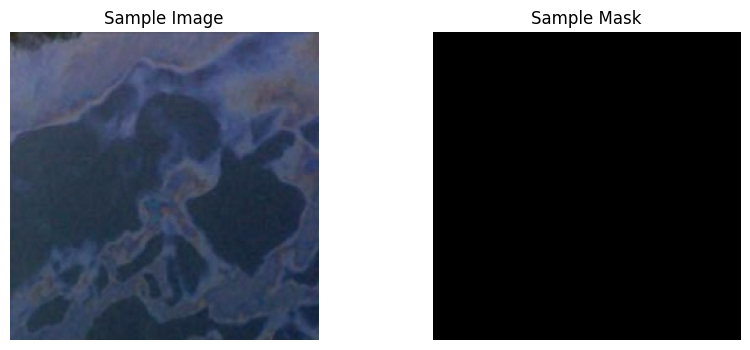

In [7]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(iter(train_ds))

print("Image batch shape:", x_batch.shape)
print("Mask batch shape :", y_batch.shape)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow((x_batch[0].numpy() + 1.0) / 2.0)  # for display only
plt.title("Sample Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(y_batch[0].numpy().squeeze(), cmap='gray')
plt.title("Sample Mask")
plt.axis("off")

plt.show()

Step 7 — Define loss and metrics

In [8]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

Step 8 — Build the optimized Edge U-Net

In [9]:
def sep_conv_block(x, filters, dropout=0.0):
    x = tf.keras.layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    if dropout > 0:
        x = tf.keras.layers.Dropout(dropout)(x)
    return x

def build_edge_unet(input_shape=(224, 224, 3), alpha=0.75):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        alpha=alpha
    )

    skip_names = [
        'block_1_expand_relu',
        'block_3_expand_relu',
        'block_6_expand_relu',
        'block_13_expand_relu',
        'block_16_project'
    ]

    skip_outputs = [base.get_layer(name).output for name in skip_names]
    encoder = tf.keras.Model(inputs=base.input, outputs=skip_outputs, name='mobilenetv2_encoder')
    encoder.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    s1, s2, s3, s4, bottleneck = encoder(inputs, training=False)

    x = bottleneck
    x = tf.keras.layers.UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = tf.keras.layers.Concatenate()([x, s4])
    x = sep_conv_block(x, 128, dropout=0.1)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = tf.keras.layers.Concatenate()([x, s3])
    x = sep_conv_block(x, 96, dropout=0.1)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = tf.keras.layers.Concatenate()([x, s2])
    x = sep_conv_block(x, 64)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = tf.keras.layers.Concatenate()([x, s1])
    x = sep_conv_block(x, 32)

    x = tf.keras.layers.UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = sep_conv_block(x, 16)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid', padding='same')(x)

    return tf.keras.Model(inputs, outputs, name='Edge_UNet_MobileNetV2')

Step 9 — Compile model

In [10]:
def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=bce_dice_loss,
        metrics=[
            dice_coef,
            tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name='iou'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

model = build_edge_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), alpha=0.75)
compile_model(model, INITIAL_LR)
model.summary()

5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Edge_UNet_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 112, 112, │  1,068,784 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 56,   │            │                   │
│                     │ 56, 144), (None,  │            │                   │
│                     │ 28, 28, 144),     │            │                   │
│                     │ (None, 14, 14,    │            │                   │
│                     │ 432), (None, 7,   │            │                   │
│                     │ 7, 240)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ mobilenetv2_enco… │
│ (UpSampling2D)      │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 672)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 14, 14,    │     92,064 │ concatenate[0][0] │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 14, 14,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 14, 14,    │     17,536 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ re_lu_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ dropout[0][0]     │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 272)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 28, 28,    │     28,560 │ concatenate_1[0]… │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        384 │ separable_conv2d… │
│ (BatchNormalizatio… │ 96)               │            │                 

 Total params: 1,250,993 (4.77 MB)

 Trainable params: 180,865 (706.50 KB)

 Non-trainable params: 1,070,128 (4.08 MB)

Step 10 — Callbacks

In [11]:
def build_callbacks(save_path, monitor='val_dice_coef'):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            save_path,
            monitor=monitor,
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor,
            mode='max',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            verbose=1
        )
    ]

Step 11 — Train stage 1

Freeze encoder first.

In [12]:
stage1_path = os.path.join(project_path, 'models', 'edge_unet_stage1_best.keras')

history_stage1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=build_callbacks(stage1_path)
)

Epoch 1/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.3623 - iou: 0.2502 - loss: 1.2312 - precision: 0.4633 - recall: 0.3525
Epoch 1: val_dice_coef improved from None to 0.24754, saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation/models/edge_unet_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation/models/edge_unet_stage1_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - dice_coef: 0.3420 - iou: 0.2699 - loss: 1.2103 - precision: 0.4569 - recall: 0.3973 - val_dice_coef: 0.2475 - val_iou: 2.4250e-04 - val_loss: 1.3362 - val_precision: 0.5906 - val_recall: 2.4254e-04 - learning_rate: 1.0000e-04
Epoch 2/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.4546 - iou: 0.4074 - loss: 1.0225 - precision: 0.6374 - recall: 0.5331
Epoch 2: val_dice_coef improved from 0.24754 to 0.38112, saving model to /content/drive/MyDrive/Oil

In [ ]:
stage1_path = os.path.join(project_path, 'models', 'edge_unet_stage1_best.keras')

history_stage1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=build_callbacks(stage1_path)
)

Epoch 1/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.3623 - iou: 0.2502 - loss: 1.2312 - precision: 0.4633 - recall: 0.3525
Epoch 1: val_dice_coef improved from None to 0.24754, saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation/models/edge_unet_stage1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation/models/edge_unet_stage1_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - dice_coef: 0.3420 - iou: 0.2699 - loss: 1.2103 - precision: 0.4569 - recall: 0.3973 - val_dice_coef: 0.2475 - val_iou: 2.4250e-04 - val_loss: 1.3362 - val_precision: 0.5906 - val_recall: 2.4254e-04 - learning_rate: 1.0000e-04
Epoch 2/20
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coef: 0.4546 - iou: 0.4074 - loss: 1.0225 - precision: 0.6374 - recall: 0.5331
Epoch 2: val_dice_coef improved from 0.24754 to 0.38112, saving model to /content/drive/MyDrive/Oil

Step 13 — Evaluate on test set

In [17]:
stage2_path = os.path.join(project_path, 'models', 'edge_unet_stage2_best.keras')

best_model = tf.keras.models.load_model(
    stage2_path,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef': dice_coef
    }
)

results = best_model.evaluate(test_ds, verbose=1)
print("Metric names:", best_model.metrics_names)
print("Test results:", dict(zip(best_model.metrics_names, results)))

43/43 ━━━━━━━━━━━━━━━━━━━━ 38s 741ms/step - dice_coef: 0.5656 - iou: 0.5923 - loss: 0.8190 - precision: 0.7326 - recall: 0.7556
Metric names: ['loss', 'compile_metrics']
Test results: {'loss': 0.8189578056335449, 'compile_metrics': 0.5655710697174072}


Step 12 — Train stage 2

In [15]:
model.load_weights(stage1_path)

for layer in model.get_layer('mobilenetv2_encoder').layers:
    layer.trainable = True

compile_model(model, FINE_TUNE_LR)

stage2_path = os.path.join(project_path, 'models', 'edge_unet_stage2_best.keras')

history_stage2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_STAGE_2,
    callbacks=build_callbacks(stage2_path)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 388 variables whereas the saved optimizer has 86 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef: 0.5504 - iou: 0.4110 - loss: 1.0845 - precision: 0.6958 - recall: 0.5022
Epoch 1: val_dice_coef improved from None to 0.49194, saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation/models/edge_unet_stage2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation/models/edge_unet_stage2_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 898s 3s/step - dice_coef: 0.5464 - iou: 0.4252 - loss: 0.9877 - precision: 0.6467 - recall: 0.5539 - val_dice_coef: 0.4919 - val_iou: 0.5049 - val_loss: 0.9221 - val_precision: 0.8311 - val_recall: 0.5626 - learning_rate: 1.0000e-05
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - dice_coef: 0.6401 - iou: 0.5202 - loss: 0.8325 - precision: 0.7661 - recall: 0.6195
Epoch 2: val_dice_coef improved from 0.49194 to 0.50321, saving model to /content/drive/MyDrive/Oil spill Research /Da

Step 14 — Visualize predictions

In [16]:
def display_predictions(model, dataset, num_samples=3):
    for images, masks in dataset.take(1):
        preds = model.predict(images)
        preds = (preds > 0.5).astype(np.float32)

        plt.figure(figsize=(12, num_samples * 4))
        for i in range(num_samples):
            plt.subplot(num_samples, 3, i*3 + 1)
            plt.imshow((images[i].numpy() + 1.0) / 2.0)
            plt.title("Image")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3 + 2)
            plt.imshow(masks[i].numpy().squeeze(), cmap='gray')
            plt.title("True Mask")
            plt.axis("off")

            plt.subplot(num_samples, 3, i*3 + 3)
            plt.imshow(preds[i].squeeze(), cmap='gray')
            plt.title("Predicted Mask")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

display_predictions(best_model, test_ds, num_samples=3)

NameError: name 'best_model' is not defined

In [31]:
!pip uninstall -y visualkeras
!pip install git+https://github.com/paulgavrikov/visualkeras

Found existing installation: visualkeras 0.2.0
Uninstalling visualkeras-0.2.0:
  Successfully uninstalled visualkeras-0.2.0
  Cloning https://github.com/paulgavrikov/visualkeras to /tmp/pip-req-build-egz5ozkn
  Running command git clone --filter=blob:none --quiet https://github.com/paulgavrikov/visualkeras /tmp/pip-req-build-egz5ozkn
  Resolved https://github.com/paulgavrikov/visualkeras to commit b5234255cf8f85315da27d6c58a8adaff6f78da8
  Preparing metadata (setup.py) ... done
  Created wheel for visualkeras: filename=visualkeras-0.2.0-py3-none-any.whl size=94072 sha256=0df20a279f77ac1adb999d79438ba1d0ed2223a809c6deb3291a406733d28a8a
  Stored in directory: /tmp/pip-ephem-wheel-cache-w6t72j4d/wheels/93/5c/60/e926df1ca6d69bb3f917bff798e0ea3d0a5a39ad739b1e4ed5
Successfully built visualkeras


In [32]:

import visualkeras
visualkeras.layered_view(model, legend=True)

/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


AttributeError: 'InputLayer' object has no attribute 'output_shape'

In [30]:
import tensorflow as tf

# Ensure the model is loaded if not already in scope from previous cells
stage2_path = os.path.join(project_path, 'models', 'edge_unet_stage2_best.keras')
best_model = tf.keras.models.load_model(
    stage2_path,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef': dice_coef
    }
)

# The graphical plotting tool is encountering persistent errors.
# We will rely on the text-based summary for architectural details.

print("Graphical model visualization failed due to library issues.")
print("You can view the model summary below for text-based details of the architecture:")
best_model.summary()

Graphical model visualization failed due to library issues.
You can view the model summary below for text-based details of the architecture:


Model: "Edge_UNet_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 112, 112, │  1,068,784 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 56,   │            │                   │
│                     │ 56, 144), (None,  │            │                   │
│                     │ 28, 28, 144),     │            │                   │
│                     │ (None, 14, 14,    │            │                   │
│                     │ 432), (None, 7,   │            │                   │
│                     │ 7, 240)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ mobilenetv2_enco… │
│ (UpSampling2D)      │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 672)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 14, 14,    │     92,064 │ concatenate[0][0] │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 14, 14,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 14, 14,    │     17,536 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ re_lu_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ dropout[0][0]     │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 272)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 28, 28,    │     28,560 │ concatenate_1[0]… │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        384 │ separable_conv2d… │
│ (BatchNormalizatio… │ 96)               │            │                 

 Total params: 3,703,093 (14.13 MB)

 Trainable params: 1,226,049 (4.68 MB)

 Non-trainable params: 24,944 (97.44 KB)

 Optimizer params: 2,452,100 (9.35 MB)

In [26]:
import tensorflow as tf

# Ensure the model is loaded if not already in scope from previous cells
stage2_path = os.path.join(project_path, 'models', 'edge_unet_stage2_best.keras')
best_model = tf.keras.models.load_model(
    stage2_path,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef': dice_coef
    }
)

# The graphical plotting tool is encountering persistent errors.
# We will rely on the text-based summary for architectural details.

print("Graphical model visualization failed due to library issues.")
print("You can view the model summary below for text-based details of the architecture:")
best_model.summary()

Graphical model visualization failed due to library issues.
You can view the model summary below for text-based details of the architecture:


Model: "Edge_UNet_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 112, 112, │  1,068,784 │ input_layer_1[0]… │
│ (Functional)        │ 96), (None, 56,   │            │                   │
│                     │ 56, 144), (None,  │            │                   │
│                     │ 28, 28, 144),     │            │                   │
│                     │ (None, 14, 14,    │            │                   │
│                     │ 432), (None, 7,   │            │                   │
│                     │ 7, 240)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ mobilenetv2_enco… │
│ (UpSampling2D)      │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 672)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 14, 14,    │     92,064 │ concatenate[0][0] │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 14, 14,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 14, 14,    │     17,536 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ re_lu_1[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ dropout[0][0]     │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 272)              │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 28, 28,    │     28,560 │ concatenate_1[0]… │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        384 │ separable_conv2d… │
│ (BatchNormalizatio… │ 96)               │            │                 

 Total params: 3,703,093 (14.13 MB)

 Trainable params: 1,226,049 (4.68 MB)

 Non-trainable params: 24,944 (97.44 KB)

 Optimizer params: 2,452,100 (9.35 MB)

In [35]:
stage2_path = os.path.join(project_path, 'models', 'edge_unet_stage2_best.keras')

def make_representative_data_gen(train_ds):
    def representative_data_gen():
        for images, _ in train_ds.take(100):
            images_np = images.numpy()
            for i in range(images_np.shape[0]):
                yield [images_np[i:i+1].astype(np.float32)]
    return representative_data_gen

def export_tflite_int8(model, train_ds, output_path):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_data_gen(train_ds)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(output_path, 'wb') as f:
        f.write(tflite_model)

    print("Saved:", output_path)

tflite_path = os.path.join(project_path, 'tflite', 'edge_unet_mobilenetv2_int8.tflite')

best_model = tf.keras.models.load_model(
    stage2_path,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef': dice_coef
    }
)

export_tflite_int8(best_model, train_ds, tflite_path)

Saved artifact at '/tmp/tmp25h2ud3k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None)
Captures:
  132640844450512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308792848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308792656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132640844449744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308793424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308792080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308793040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308793232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308792272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132639308794384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved: /content/drive/MyDrive/Oil spill Research /Dataset Cretaion /Edge_UNet_binary_segmentation/tflite/edge_unet_mobilenetv2_int8.tflite


In [34]:
print("Confusion Matrix:\n")
print(cm)

# Ensure tflite_path is defined and the model is exported before calculating its size
tflite_path = os.path.join(project_path, 'tflite', 'edge_unet_mobilenetv2_int8.tflite')

# The best_model and train_ds should be in scope from previous executions.
# If not, they would need to be reloaded/recreated here.
# For this fix, we assume best_model and train_ds are available.
export_tflite_int8(best_model, train_ds, tflite_path)

# Get TFLite model size
tflite_model_size_bytes = os.path.getsize(tflite_path)
tflite_model_size_mb = tflite_model_size_bytes / (1024 * 1024)
print(f"\nTFLite Model Size: {tflite_model_size_mb:.2f} MB")

Confusion Matrix:

[[11592578  1214266]
 [ 1076269  3327255]]


NameError: name 'export_tflite_int8' is not defined

### Suggestions for Improvement:

Based on the performance metrics and training history (where a gap between training and validation metrics was observed), here are some suggestions for potentially improving the model:

1.  **Hyperparameter Tuning:** Experiment with different learning rates, batch sizes, and optimizer parameters. You could use techniques like Grid Search or Random Search.
2.  **Regularization:** If overfitting is suspected, consider adding more regularization techniques such as:
    *   **Dropout:** Increase dropout rates in the `sep_conv_block` function.
    *   **L1/L2 Regularization:** Add L1 or L2 regularization to convolutional layers.
    *   **Early Stopping Patience:** While early stopping is already in place, increasing its `patience` might allow the model to train longer and potentially find a better minimum if it's currently stopping too soon.
3.  **Data Augmentation:** While some augmentation is used, explore more advanced or aggressive augmentation techniques to increase the diversity of the training data (e.g., more variations in rotation, zoom, brightness, contrast, or color jitter).
4.  **Ensemble Methods:** Combine predictions from multiple models (e.g., different Edge U-Nets trained with varying initializations or slight architectural differences) to potentially improve overall robustness and performance.
5.  **Loss Function Exploration:** Experiment with different weighting for the BCE and Dice components in `bce_dice_loss` or try other loss functions specifically designed for segmentation tasks, such as Focal Loss for imbalanced classes (if spill pixels are rare).
6.  **Transfer Learning Fine-tuning:** Even though the encoder was fine-tuned in Stage 2, you could explore different `alpha` values for MobileNetV2 (e.g., `alpha=1.0` for a larger base model) or experiment with different pre-trained backbones altogether.
7.  **Post-processing:** Apply morphological operations (like erosion or dilation) to the predicted masks to refine boundaries and reduce noise, which can sometimes improve Dice/IoU scores.

These suggestions aim to address potential areas of improvement, especially regarding the observed generalization gap between training and validation performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 971ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590

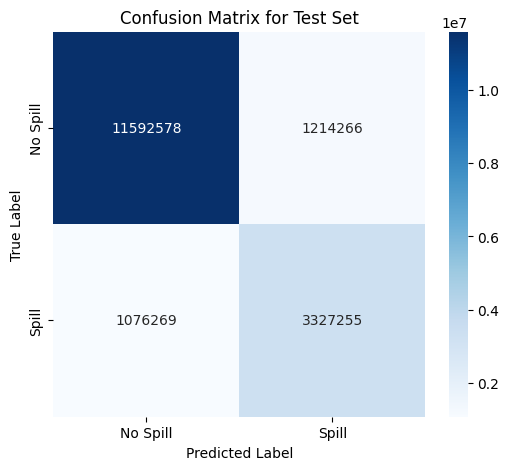

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Reload the best model to ensure it's defined and loaded correctly
stage2_path = os.path.join(project_path, 'models', 'edge_unet_stage2_best.keras')
best_model = tf.keras.models.load_model(
    stage2_path,
    custom_objects={
        'bce_dice_loss': bce_dice_loss,
        'dice_coef': dice_coef
    }
)

all_true_masks = []
all_pred_masks = []

for images, masks in test_ds:
    preds = best_model.predict(images)
    preds = (preds > 0.5).astype(np.float32)

    all_true_masks.append(masks.numpy().flatten())
    all_pred_masks.append(preds.flatten())

true_masks_flat = np.concatenate(all_true_masks)
pred_masks_flat = np.concatenate(all_pred_masks)

cm = confusion_matrix(true_masks_flat, pred_masks_flat)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Spill', 'Spill'], yticklabels=['No Spill', 'Spill'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()

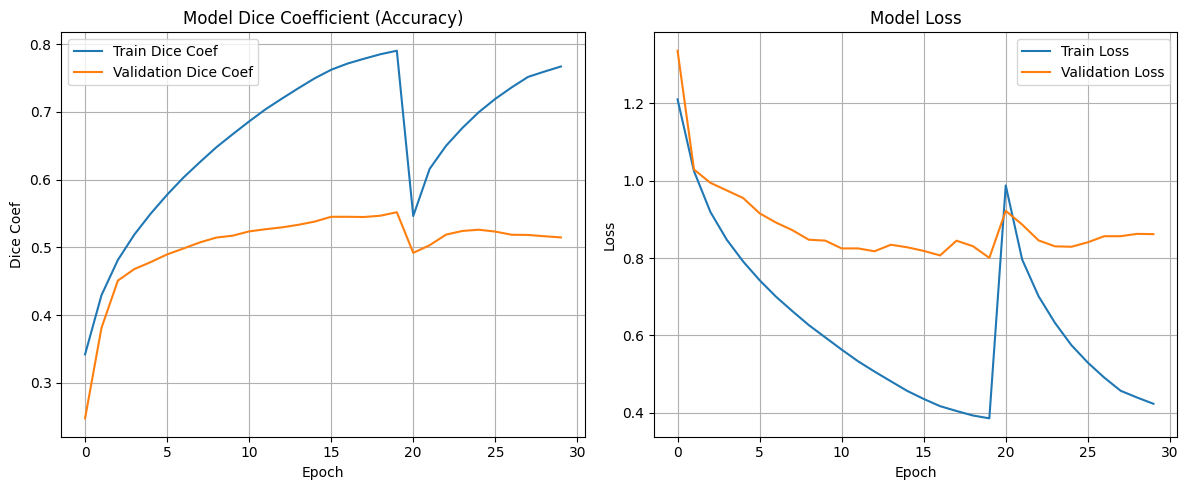

In [18]:
import matplotlib.pyplot as plt

# Combine histories if both exist
if 'history_stage1' in locals() and 'history_stage2' in locals():
    # Use only keys that are common to both histories to avoid errors
    common_keys = set(history_stage1.history.keys()).intersection(set(history_stage2.history.keys()))
    combined_history = {key: history_stage1.history[key] + history_stage2.history[key] for key in common_keys}
else:
    print("Warning: One or both history objects are missing. Plotting only available history.")
    combined_history = history_stage1.history if 'history_stage1' in locals() else history_stage2.history

# Plot Dice Coefficient
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(combined_history['dice_coef'], label='Train Dice Coef')
plt.plot(combined_history['val_dice_coef'], label='Validation Dice Coef')
plt.title('Model Dice Coefficient (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Dice Coef')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(combined_history['loss'], label='Train Loss')
plt.plot(combined_history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Based on the plots, we can make the following suggestions:

Step 15 — Export int8 TFLite model

This supports your edge/UAV objective in the proposal.

In [ ]:
def make_representative_data_gen(train_ds):
    def representative_data_gen():
        for images, _ in train_ds.take(100):
            images_np = images.numpy()
            for i in range(images_np.shape[0]):
                yield [images_np[i:i+1].astype(np.float32)]
    return representative_data_gen

def export_tflite_int8(model, train_ds, output_path):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_data_gen(train_ds)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(output_path, 'wb') as f:
        f.write(tflite_model)

    print("Saved:", output_path)

tflite_path = os.path.join(project_path, 'tflite', 'edge_unet_mobilenetv2_int8.tflite')
export_tflite_int8(best_model, train_ds, tflite_path)